In [14]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

file_path = "HTRU_2.csv"
df = pd.read_csv(file_path)

df.head(), df.shape

(     140.5625  55.68378214  -0.234571412  -0.699648398  3.199832776  \
 0  102.507812    58.882430      0.465318     -0.515088     1.677258   
 1  103.015625    39.341649      0.323328      1.051164     3.121237   
 2  136.750000    57.178449     -0.068415     -0.636238     3.642977   
 3   88.726562    40.672225      0.600866      1.123492     1.178930   
 4   93.570312    46.698114      0.531905      0.416721     1.636288   
 
    19.11042633  7.975531794  74.24222492  0  
 0    14.860146    10.576487   127.393580  0  
 1    21.744669     7.735822    63.171909  0  
 2    20.959280     6.896499    53.593661  0  
 3    11.468720    14.269573   252.567306  0  
 4    14.545074    10.621748   131.394004  0  ,
 (17897, 9))

In [12]:
print("\nClass distribution:")
print(df["class"].value_counts())

print("\nData preview:")
print(df.head())

print("\nData info:")
print(df.info())


Class distribution:
class
0    16259
1     1639
Name: count, dtype: int64

Data preview:
      mean_ip     std_ip  kurtosis_ip  skewness_ip  mean_dm_snr  std_dm_snr  \
0  140.562500  55.683782    -0.234571    -0.699648     3.199833   19.110426   
1  102.507812  58.882430     0.465318    -0.515088     1.677258   14.860146   
2  103.015625  39.341649     0.323328     1.051164     3.121237   21.744669   
3  136.750000  57.178449    -0.068415    -0.636238     3.642977   20.959280   
4   88.726562  40.672225     0.600866     1.123492     1.178930   11.468720   

   kurtosis_dm_snr  skewness_dm_snr  class  
0         7.975532        74.242225      0  
1        10.576487       127.393580      0  
2         7.735822        63.171909      0  
3         6.896499        53.593661      0  
4        14.269573       252.567306      0  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  

In [15]:
columns = [
    "mean_ip",
    "std_ip",
    "kurtosis_ip",
    "skewness_ip",
    "mean_dm_snr",
    "std_dm_snr",
    "kurtosis_dm_snr",
    "skewness_dm_snr",
    "class"
]

df = pd.read_csv(file_path, header=None, names=columns)


X = df.drop("class", axis=1)
y = df["class"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9727362898628988

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3252
           1       0.78      0.92      0.85       328

    accuracy                           0.97      3580
   macro avg       0.89      0.95      0.92      3580
weighted avg       0.97      0.97      0.97      3580



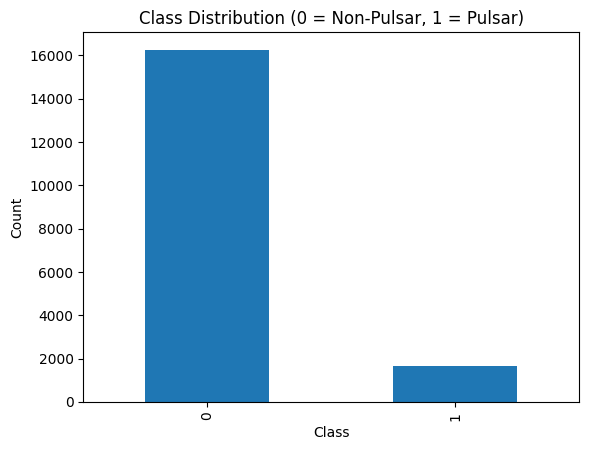

In [17]:
plt.figure()
df["class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution (0 = Non-Pulsar, 1 = Pulsar)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

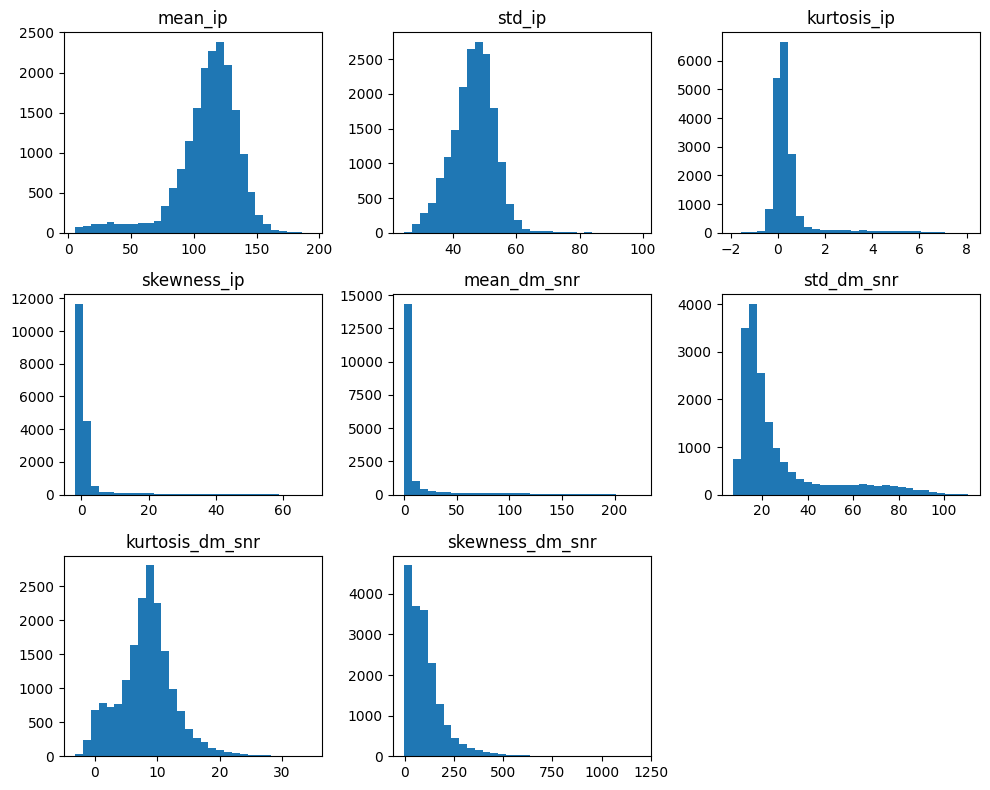

In [18]:
numeric_cols = df.columns[:-1]

plt.figure(figsize=(10, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[col], bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

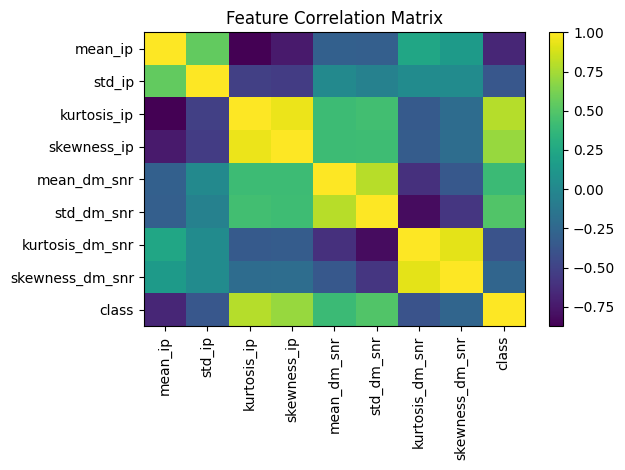

In [19]:

corr = df.corr()
plt.figure()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()